Total Energy 100
Number of harmonic oscillators for Subsystem A 300
Number of harmonic oscillators for Subsystem B 200


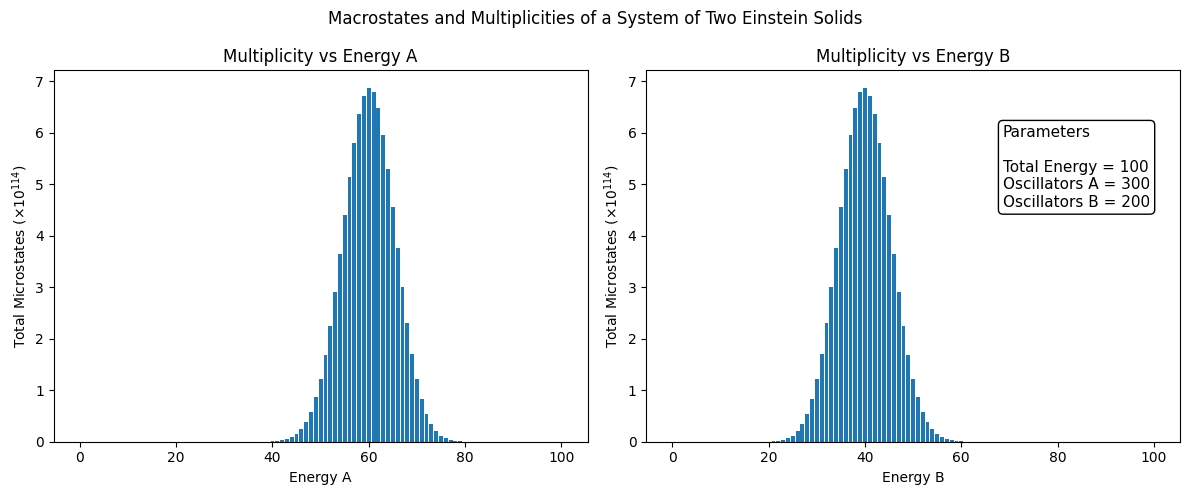

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider as sd
import pandas as pd
import math

numsys = 2
energy = int(input("Total Energy "))

energy_a = np.array([i for i in range(energy+1)])
energy_b = np.array([i for i in range(energy, -1, -1)])
number_a = int(input("Number of harmonic oscillators for Subsystem A "))
number_b = int(input("Number of harmonic oscillators for Subsystem B "))

#Multiplicities for Each System with Total Multiplicity
microstate_a = np.array([math.comb(energy_a[i] + number_a - 1, energy_a[i]) for i in range(energy + 1)])
microstate_b = np.array([math.comb(energy_b[i] + number_b - 1, energy_b[i]) for i in range(energy + 1)])
totalmicrostate = microstate_a * microstate_b

# Automatic scaling for the Plot
max_value = max(totalmicrostate)          # Largest multiplicity
target_power = len(str(max_value)) - 1    # Number of digits - 1
scaling_factor = 10**target_power
scaled_totalmicrostate = np.array(
    [x / scaling_factor for x in totalmicrostate], dtype=float)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Macrostates and Multiplicities of a System of Two Einstein Solids')

# Histogram for Energy A
axs[0].bar(energy_a, scaled_totalmicrostate, width=0.8)
axs[0].set_xlabel("Energy A")
axs[0].set_ylabel(f"Total Microstates ($\\times 10^{{{target_power}}}$)")
axs[0].set_title("Multiplicity vs Energy A")

# Histogram for Energy B
axs[1].bar(energy_b, scaled_totalmicrostate, width=0.8)
axs[1].set_xlabel("Energy B")
axs[1].set_ylabel(f"Total Microstates ($\\times 10^{{{target_power}}}$)")
axs[1].set_title("Multiplicity vs Energy B")

#Parameters on a Textbox
plt.subplots_adjust(right=0.82)

fig.text(
    0.84, 0.75,
    f"Parameters\n\n"
    f"Total Energy = {energy}\n"
    f"Oscillator A = {number_a}\n"
    f"Oscillator B = {number_b}",
    va='top',
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round')
)
plt.tight_layout()
plt.show()